In [1]:

import os
# Make sure you are in scMEDAL_for_scRNAseq dir
os.chdir("/archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq")

#from models.models import train_model_on_named_experiment

In [3]:

os.getcwd()

'/endosome/archive/bioinformatics/DLLab/src/AixaAndrade/gitfront/dev2/scMEDAL_for_scRNAseq'

## Training Models:

#### Implemented Models:
| Model Class | Model Description | 
|------------|--------------------|  
| `AE` | Autoencoder | 
| `AEC`| Autoencoder Classifier |
| `scMEDAL-FE` | Domain Adversarial Autoencoder |
| `scMEDAL-FEC`| Domain Adversarial Autoencoder Classifier |
| `scMEDAL-RE`| Domain Enhancing Autoencoder Classifier | 

#### Named Experiments:
| Valid Named Experiment | Dataset |  n_clusters | n_pred |
|------------------------|---------|-------------|--------|
| `AML`| Acute Myeloid Leukemia | 19 | 21 |
| `ASD`| Autism Spectrum Disorder | 31 | 17 | 
| `HH` | Healthy Heart | 147 | 13 | 

**Note:** If training on other datasets, the configs will need to be passed in as dictionaries to `model_kwargs` and `train_kwargs`.

`quick` is a boolean flag that can be passed to `train_kwargs` which shortens training to only 1 fold for 3 epochs.

Run models on all 3 datasets with

$python\ run\_scMEDAL\_alldatasets.py$

## Analyzing Models:

When you run a model, it generates the following output directories:
   - /outputs/figures
   - /outputs/latent_space
   - /outputs/saved_models
 
 Inside each of these directories, there is a subdirectory named after the model and its run identifier.
 
 For example: $ASD/latent\_space/scmedalfe/run\_crossval\_<run\_name>$

 To analyze your results, copy the corresponding $<run\_name>$ below.

In [2]:

# When you run your model, it outputs the figures, latent_space and saved_models directories, whitin those directories you will find a subdir with the name of the model trained, example: AML/latent_space/scmedalfe/run_crossval_<run_name>
# Please copy the <run_name below> to analyze the results
# Update output paths of the models that you just run

from utils.defaults import ASD_OUTPUTS_DIR,ASD_EXPERIMENT_NAME
print(f"Loading outputs from {ASD_OUTPUTS_DIR}. Please verify that your models output folder is located here before proceeding with the analysis.")
import os
model_folder_dict = {
    "ae":"run_crossval_n_latent_dims-50_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-50_get_cf_batch-False_2025-07-10_03-10",
    "aec":"run_crossval_n_latent_dims-50_layer_units-512-132_n_pred-17_use_batch_norm-True_scaling-min_max_model_type-aec_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_get_cf_batch-False_2025-07-10_05-16",
    "scmedalfe":"run_crossval_loss_gen_weight-1_loss_recon_weight-1000_loss_class_weight-1_n_latent_dims-50_layer_units-512-132_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-09_22-12",
    "scmedalfec":"run_crossval_loss_gen_weight-1_loss_recon_weight-2000_loss_class_weight-1_n_latent_dims-50_layer_units-512-132_scaling-min_max_model_type-scmedalfec_batch_size-512_epochs-500_patience-30_sample_size-10000_get_cf_batch-False_2025-07-10_00-42",
    "scmedalre":"run_crossval_loss_recon_weight-110_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-10_07-53",

    # To collect the comparable outputs (see below), you need to run the comparable models in /comparables. 

    # new runs
    "scVI":"run_crossval_n_latent_dims-50_n_layers-2_n_hidden-132_gene_likelihood-zinb_dispersion-gene_scaling-min_max_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_2025-07-16_23-16",
    "scANVI":"run_crossval_n_latent_dims-50_n_layers-2_n_hidden-132_gene_likelihood-zinb_dispersion-gene_scaling-min_max_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_2025-07-16_23-26",
    "scanorama":"run_crossval_n_latent_dims-50_scaling-min_max_sample_size-10000_model_type-ae_2025-07-16_23-33",
    "harmony":"run_crossval_n_latent_dims-50_scaling-min_max_sample_size-10000_model_type-ae_2025-07-16_23-39",
    "SAUCIE":"run_crossval_n_latent_dims-50_layers-512-132-50_lambda_b-0.0_lambda_c-0.0_lambda_d-0.0_learning_rate-0.0_scaling-min_max_batch_size-512_epochs-50_patience-30_sample_size-10000_model_type-ae_2025-07-17_00-36",
        }
        

model_paths = {k:os.path.join(ASD_OUTPUTS_DIR, "latent_space", ASD_EXPERIMENT_NAME,k, v) for k, v in model_folder_dict.items()}


OUTPUTS_DIR: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs
Loading outputs from /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/ASD. Please verify that your models output folder is located here before proceeding with the analysis.


##### Step 1: Import the analysis class and initialize it

In [3]:

import analysis.analysis as aa

#analysis_name = "ASD_default_500_v1.3"
analysis_name = "ASD_default_500"



asd = aa.ASDAnalysis(model_folder_dict, analysis_name)

2025-07-31 14:28:39.902517: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-31 14:28:41.803028: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


##### Step 2: Compile clustering scores calculated after training the models

In [4]:


res= asd.clustering_scores(model_folder_dict)
# You can now inspect or export `clustering_results` as needed
# Note: if you only run 1 fold, you will see NAN in CI entries
res

[WARN] scVI: config.json not found: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/ASD/saved_models/log_transformed_2916hvggenes/scVI/run_crossval_n_latent_dims-50_n_layers-2_n_hidden-132_gene_likelihood-zinb_dispersion-gene_scaling-min_max_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_2025-07-16_23-16/configs.json  using single-model format (AE will default to PCA format if present)
[WARN] scANVI: config.json not found: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/ASD/saved_models/log_transformed_2916hvggenes/scANVI/run_crossval_n_latent_dims-50_n_layers-2_n_hidden-132_gene_likelihood-zinb_dispersion-gene_scaling-min_max_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_2025-07-16_23-26/configs.json  using single-model format (AE will default to PCA format if present)
[WARN] scanorama: config.jso

batch                                                        \
                1/db                       ch                   silhouette   
                mean CI_lower CI_upper   mean CI_lower CI_upper       mean   
dataset_type                                                                 
X_pca_test      0.09     0.09     0.10  25.74    25.16    26.33      -0.09   
ae_latent_test  0.09     0.09     0.10  24.67    24.05    25.29      -0.10   
SAUCIE          0.08     0.08     0.08  12.49     7.76    17.22      -0.18   
aec             0.06     0.05     0.07  18.46    12.89    24.03      -0.17   
harmony         0.07     0.04     0.10  18.38     8.73    28.04      -0.09   
scANVI          0.06     0.06     0.07  15.56    14.67    16.46      -0.15   
scVI            0.06     0.05     0.06  11.83    10.97    12.69      -0.15   
scanorama       0.08     0.05     0.10  20.37    12.96    27.78      -0.12   
scmedalfe       0.09     0.08     0.09  13.87    10.52    17.21      -0.05   
scmedalfec      0.08     0.08     0.09  16.88    15.71    18.05      -0.08   
scmedalre       0.22     0.20     0.24  80.93    45.70   116.16      -0.02   

                                 celltype                                      \
                                     1/db                         ch            
               CI_lower CI_upper     mean CI_lower CI_upper     mean CI_lower   
dataset_type                                                                    
X_pca_test        -0.10    -0.09     0.46     0.45     0.47  1440.09  1427.94   
ae_latent_test    -0.11    -0.09     0.44     0.43     0.44  1523.30  1432.99   
SAUCIE            -0.21    -0.15     0.45     0.41     0.48  1716.57  1295.78   
aec               -0.21    -0.14     0.67     0.65     0.70  5739.65  4529.05   
harmony           -0.10    -0.09     0.45     0.43     0.46  1479.23  1393.49   
scANVI            -0.15    -0.14     1.13     1.05     1.21  6512.85  5885.91   
scVI              -0.17    -0.13     0.43     0.39     0.46  4518.33  4303.85   
scanorama         -0.15    -0.08     0.43     0.39     0.47  2136.42  1163.33   
scmedalfe         -0.07    -0.03     0.37     0.34     0.39   709.87   486.10   
scmedalfec        -0.09    -0.07     0.37     0.36     0.37  1023.36   959.74   
scmedalre         -0.04     0.00     0.32     0.29     0.35   641.18   509.68   

                                                      
                        silhouette                    
               CI_upper       mean CI_lower CI_upper  
dataset_type                                          
X_pca_test      1452.23       0.20     0.20     0.21  
ae_latent_test  1613.62       0.20     0.19     0.21  
SAUCIE          2137.35       0.11     0.06     0.15  
aec             6950.24       0.32     0.29     0.35  
harmony         1564.98       0.20     0.20     0.21  
scANVI          7139.78       0.50     0.48     0.52  
scVI            4732.81       0.34     0.33     0.34  
scanorama       3109.51       0.26     0.18     0.33  
scmedalfe        933.64       0.14     0.11     0.17  
scmedalfec      1086.99       0.17     0.16     0.18  
scmedalre        772.68       0.12     0.10     0.14

##### Step 3: Generate and save the UMAP plots

In [4]:

# This typically loads latent representations stored after training and creates UMAPs for each model
processors = asd.umap(model_folder_dict, types=["train"], splits=[1])
processors

Reading inputs and latent paths ..
umap saved to /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/ASD/compare_models/log_transformed_2916hvggenes/ASD_default_500/umap_31batches_seed_5
Computing UMAP projections...


Processing input prefix: 0 train_1
Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/ASD_data/reverse_norm/log_transformed_2916hvggenes/splits/split_1/train


In [5]:
# Visualize the generated umap images for scmedalre 
from IPython.display import HTML, display
import glob

outputs_path = os.path.join(asd.paths.outputs_path, analysis_name)
# Make sure this path leads to the stored umap figures
figs_list    = glob.glob(outputs_path + "/*umap*/*plots_axis/*umap*scmedalre*")

html = (
    "<div style='display:flex; flex-wrap:wrap; gap:10px;'>"
    + "".join(f"<img src='{fig}' style='max-width:380px;'>" for fig in figs_list)
    + "</div>"
)
display(HTML(html))

##### Step 4: Run genomaps on a subsample of the input data along with reconstructions from the scmedalfe and scmedalre models. 

Visualize selected batches to assess batch-specific effects in the reconstructed spaces, including conterfactual projections from scmedalre.

In [6]:
# Run genomaps on a subsample input+scmedalfe recon +scmedal re recon for different batches
dict_batches = {
    "donor_5531": "ASD",
    "donor_5945": "ASD",
    "donor_5419": "ASD",
    "donor_6032": "control",
    "donor_5242": "control",
    "donor_5976": "control",
}
print("dict_batches:", dict_batches)

batches = [
    "donor_5531",
    "donor_5945",
    "donor_5419",
    "donor_6032",
    "donor_5242",
    "donor_5976",
]


# for this genomap config, you need to compute first the reconstructions from scMEDAL-FE and scMEDAL-RE
selected_models = {k: model_folder_dict[k] for k in ("scmedalfe", "scmedalre")}
gfd = asd.genomap(selected_models,
                            n_batches = 31,
                            num_iter = 200, # for quick test, otherwise 100
                            cell_id_col = "cell",
                            gene_index_col = "gene_ids",
                            celltype = ["L2/3"],
                            batches=batches,
                            models=['scmedalre'],#if add_inputs_fe=True-> scmedalfe+ inputs are used for genomap creation by default, no need to add the to the list, 
                            types=["train"], 
                            splits=[1],
                            add_inputs_fe= True,
                            extra_recon = "fe",
                            min_val = -1,
                            max_val = 3 )

dict_batches: {'donor_5531': 'ASD', 'donor_5945': 'ASD', 'donor_5419': 'ASD', 'donor_6032': 'control', 'donor_5242': 'control', 'donor_5976': 'control'}
Analysis paths: {'experiment_name': 'ASD', 'analysis_name': 'ASD_default_500', 'data_path': '/archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/data/ASD_data', 'data_folder_name': 'log_transformed_2916hvggenes', 'splits_path': '/archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/data/ASD_data/log_transformed_2916hvggenes/splits', 'outputs_path': '/archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/ASD/compare_models/log_transformed_2916hvggenes', 'model_results_folder_dict': {'scmedalfe': 'run_crossval_loss_gen_weight-1_loss_recon_weight-1000_loss_class_weight-1_n_latent_dims-50_layer_units-512-132_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-09_22-12', 'scmedalre': 'run_crossval_loss_r

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


adata_mb AnnData object with n_obs × n_vars = 9900 × 2916
    obs: 'Unnamed: 0.1', 'Unnamed: 0', 'cell', 'cluster', 'sample', 'individual', 'region', 'age', 'sex', 'diagnosis', 'Capbatch', 'Seqbatch', 'post-mortem interval (hours)', 'RNA Integrity Number', 'genes', 'UMIs', 'RNA mitochondr. percent', 'RNA ribosomal percent', 'celltype', 'donor', 'batch', 'n_genes', 'original_index', 'recon_prefix'
    var: 'Unnamed: 0', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_names'
cells selected from the following batches ['donor_5531', 'donor_5945', 'donor_5419', 'donor_6032', 'donor_5242', 'donor_5976']
TCGCGAGAGACATAAC-1_5531_BA24 comes from batch donor_5531
TCACAAGTCTGCTTGC-1_5945_PFC comes from batch donor_5945
TTCTACATCACCGGGT-1_5419_PFC comes from batch donor_5419
ACCGTAACAAGGACAC-1_6032_BA24 comes from batch donor_6032
CATTCGCCAAGCTGGA-1_5242_BA24 comes from batch donor_5242
GGAAAGCAGAAGGACA-1_5976_BA9 comes from batch donor_5976
Original batch list: ['d

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Input does not contain NaNs
subset_input_z_scores shape: (9900, 2916)


...

created plot with no gene labels
plotting small panel for CATTCGCCAAGCTGGA-1_5242_BA24 with original batch donor_5242 and celltype L2/3, n recons: 8
Saved gene std across batches  to: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/ASD/compare_models/log_transformed_2916hvggenes/ASD_default_500/genomap/genomap_plots/singlecell_gene_std_acrossbatches/genomap_CATTCGCCAAGCTGGA-1_5242_BA24_std_10topvariablegenesacrossbatches.csv


plotting big panel for single cell CATTCGCCAAGCTGGA-1_5242_BA24 from original batch donor_5242 and celltype L2/3, n recons: 33


/endosome/archive/bioinformatics/DLLab/src/AixaAndrade/gitfront/dev2/scMEDAL_for_scRNAseq/utils/genomaps_utils.py:1032: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 0.9, 0.97])


created plot with no gene labels
plotting small panel for GGAAAGCAGAAGGACA-1_5976_BA9 with original batch donor_5976 and celltype L2/3, n recons: 8
Saved gene std across batches  to: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/ASD/compare_models/log_transformed_2916hvggenes/ASD_default_500/genomap/genomap_plots/singlecell_gene_std_acrossbatches/genomap_GGAAAGCAGAAGGACA-1_5976_BA9_std_10topvariablegenesacrossbatches.csv


plotting big panel for single cell GGAAAGCAGAAGGACA-1_5976_BA9 from original batch donor_5976 and celltype L2/3, n recons: 33


/endosome/archive/bioinformatics/DLLab/src/AixaAndrade/gitfront/dev2/scMEDAL_for_scRNAseq/utils/genomaps_utils.py:1032: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 0.9, 0.97])


created plot with no gene labels


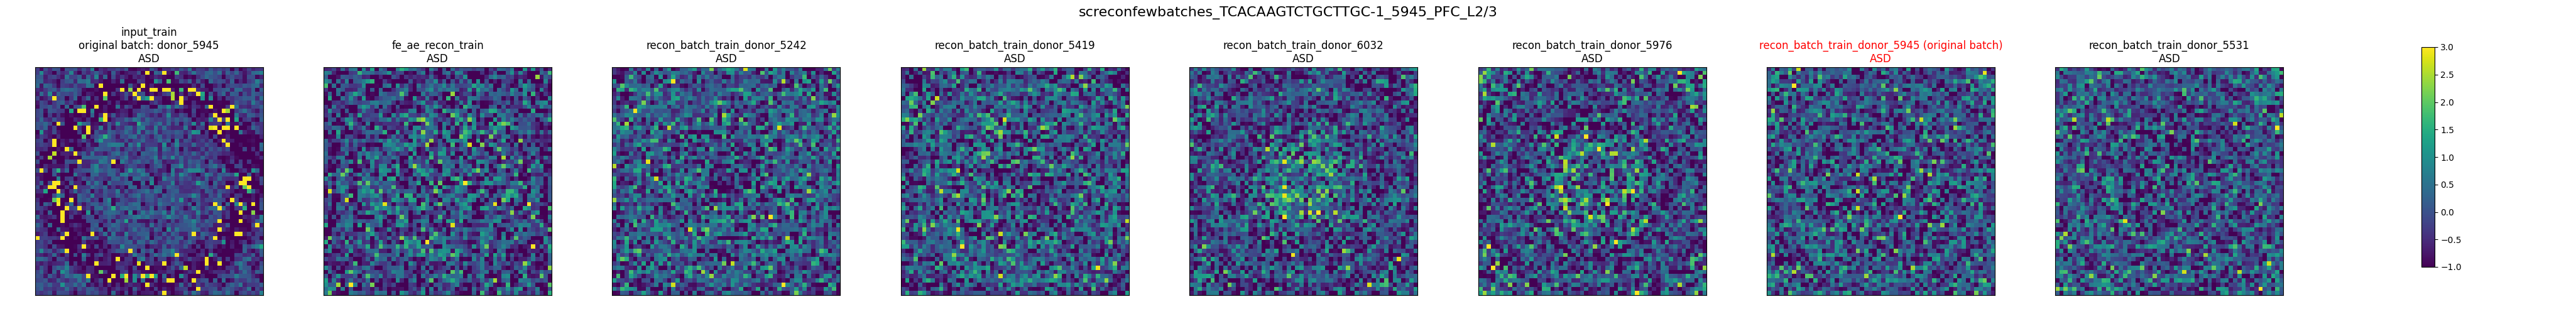

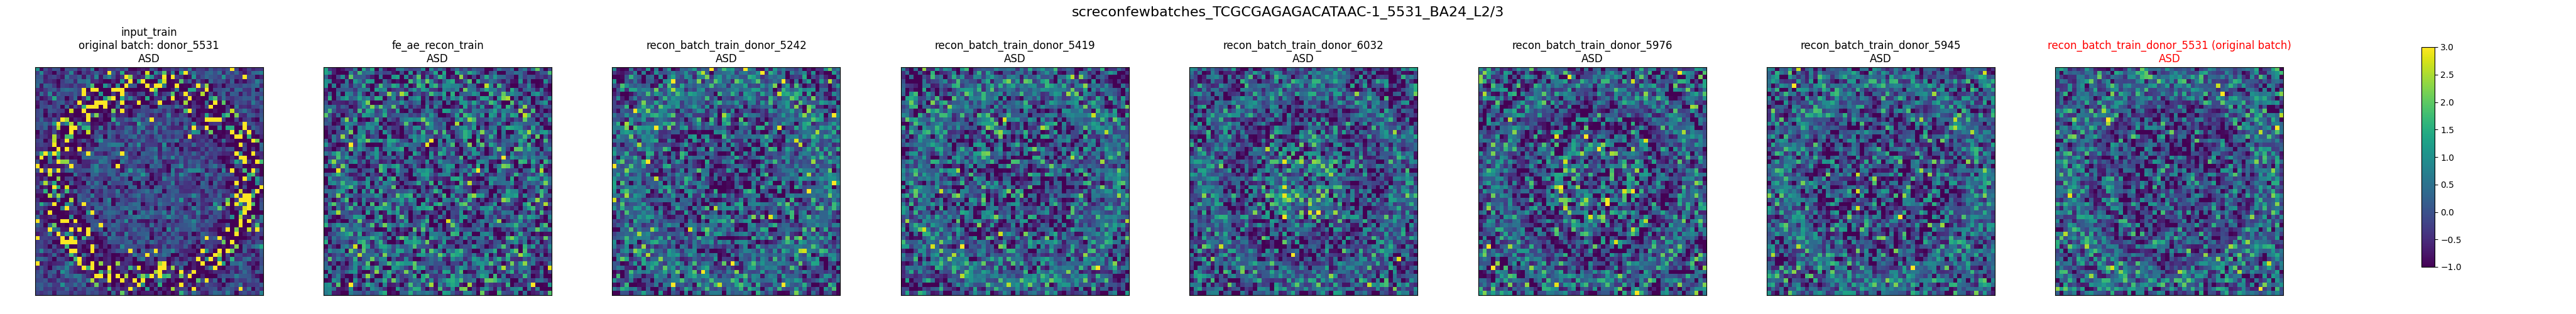

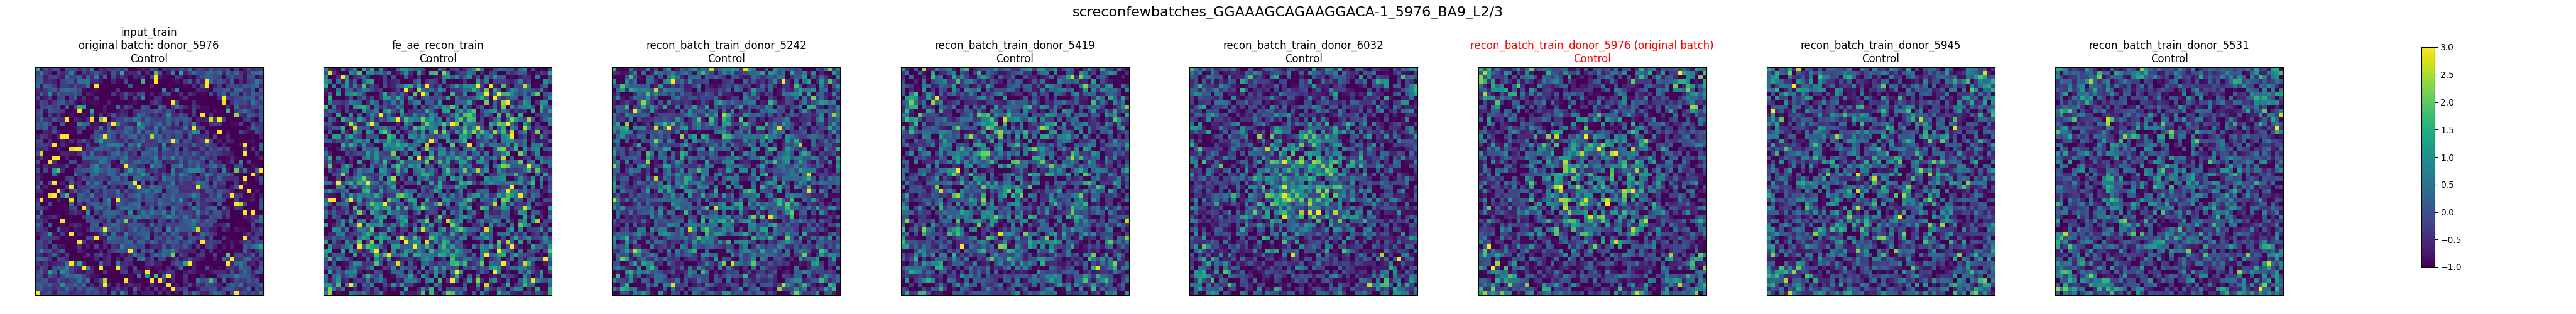

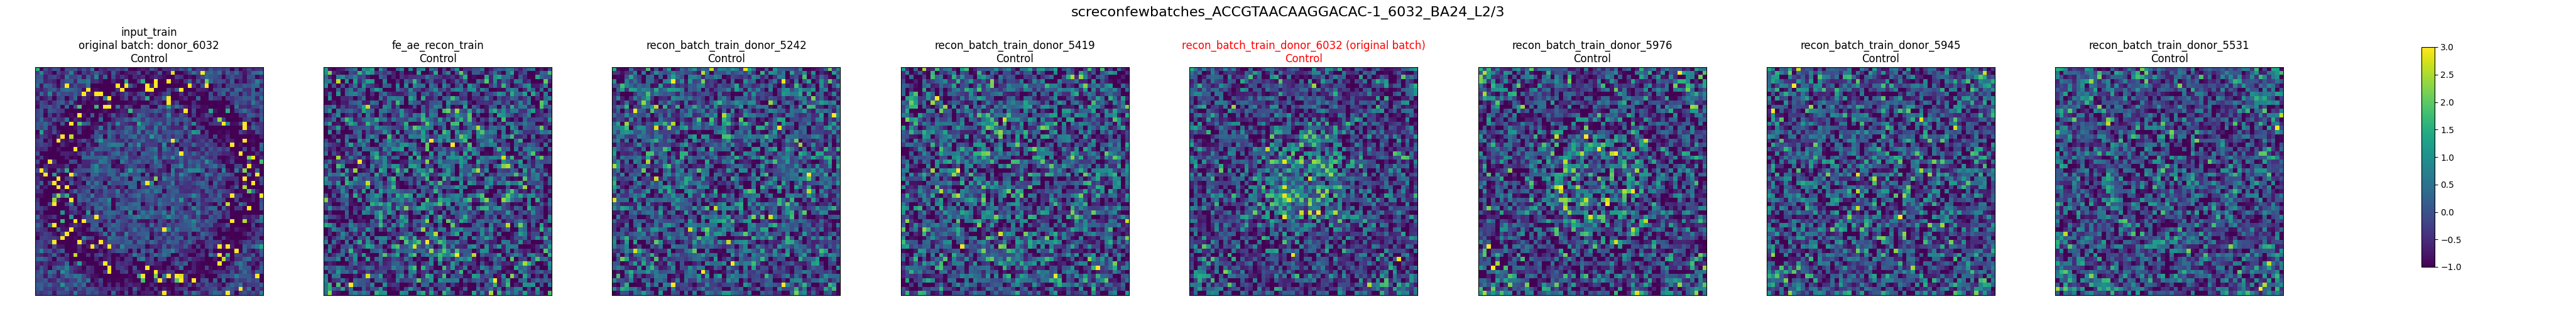

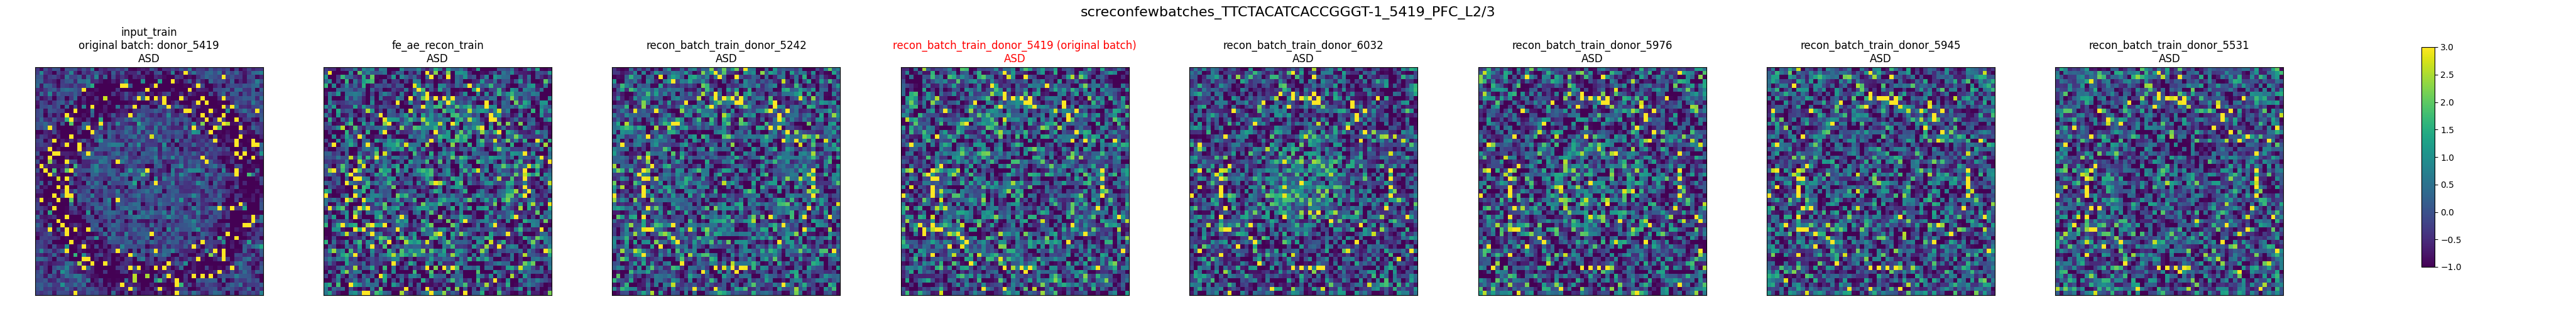

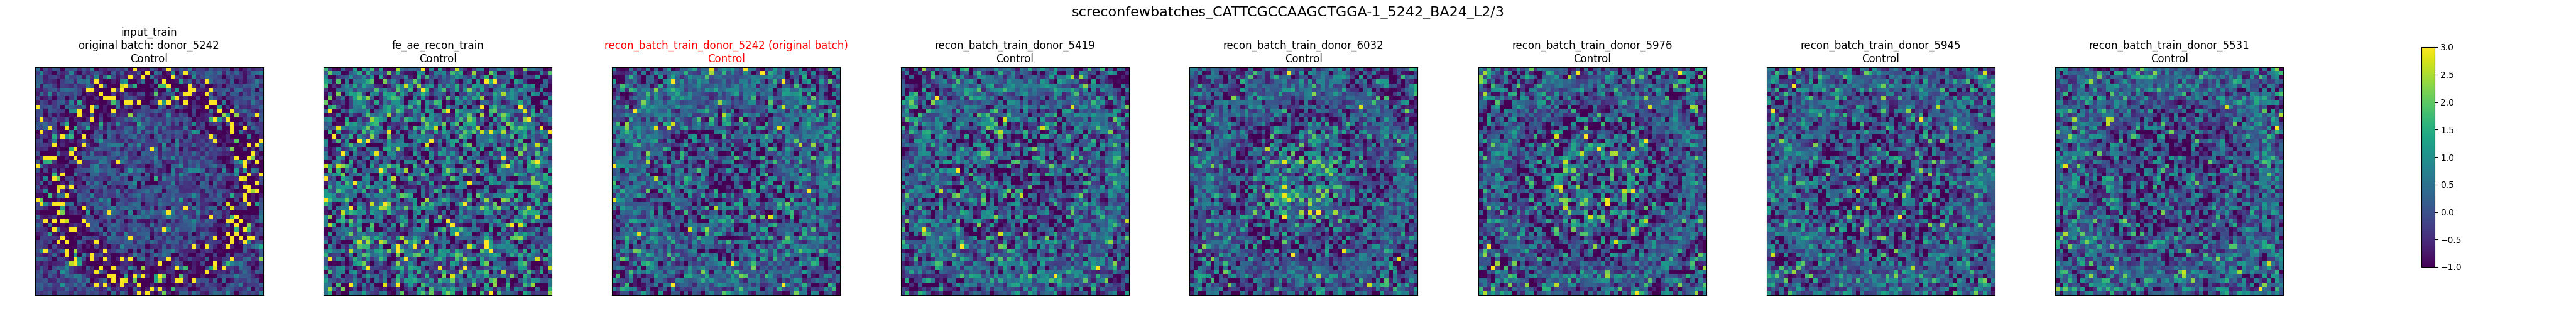

In [8]:
# View genomap images
from IPython.display import Image, display


genomap_path = os.path.join(
    asd.paths.outputs_path, 
    analysis_name, 
    "genomap", 
    "genomap_plots"
)
# Make sure this path leads to the stored genomap figures
figs_list = glob.glob(
    os.path.join(genomap_path, "*genomap_plots_scfewbatches_nogenelabels", "*")
)


# Show all figures
for fig in figs_list:
    display(Image(filename=fig))

## Run the Mixed Effects Classifier (MEC) on latent spaces generated by scmedalfe and scmedalre.

Classification target: 2 patient groups (e.g., ASD vs. Control)

$python\ mec\_asd.py$

In [5]:
# Now get a summary table of all mec results
from utils.compare_results_utils import get_all_mec_metrics
df,_ = get_all_mec_metrics(ASD_OUTPUTS_DIR,ASD_EXPERIMENT_NAME, split='test')
df


MEC RF summary able saved to /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/ASD/latent_space/log_transformed_2916hvggenes/mec/MEC_RF_summary.csv


,latent,RFAccuracy_mean,RFAccuracy_95CI_lower,RFAccuracy_95CI_upper,RFBalancedAccuracy_mean,RFBalancedAccuracy_95CI_lower,RFBalancedAccuracy_95CI_upper,ChanceAccuracy_mean,ChanceAccuracy_95CI_lower,ChanceAccuracy_95CI_upper,run_name
0,harmony_latent,57.05,56.61,57.48,57.06,56.62,57.49,50.06,49.75,50.37,harmony_latent_n_pred-2_bio_col-diagnosis_2025...
0,scANVI_latent,59.88,59.70,60.06,59.88,59.70,60.06,50.06,49.75,50.37,scANVI_latent_n_pred-2_bio_col-diagnosis_2025-...
0,scVI_latent,63.14,62.71,63.56,63.13,62.70,63.56,50.06,49.75,50.37,scVI_latent_n_pred-2_bio_col-diagnosis_2025-07...
0,scanorama_latent,65.75,64.19,67.31,65.76,64.20,67.32,50.06,49.75,50.37,scanorama_latent_n_pred-2_bio_col-diagnosis_20...
0,scmedalfec_latent,66.84,65.58,68.11,66.85,65.59,68.11,50.06,49.75,50.37,scmedalfec_latent_n_pred-2_bio_col-diagnosis_2...
0,scmedalfe_latent,67.44,66.39,68.49,67.45,66.40,68.49,50.06,49.75,50.37,scmedalfe_latent_n_pred-2_bio_col-diagnosis_20...
0,SAUCIE_latent,70.57,69.44,71.70,70.58,69.44,71.72,50.06,49.75,50.37,SAUCIE_latent_n_pred-2_bio_col-diagnosis_2025-...
0,X_pca,73.12,72.92,73.32,73.13,72.93,73.34,50.06,49.75,50.37,X_pca_n_pred-2_bio_col-diagnosis_2025-07-17_12-02
0,scmedalfec_latent_re_latent-scmedalre_latent,90.02,86.19,93.84,90.02,86.20,93.84,50.06,49.75,50.37,scmedalfec_latent_re_latent-scmedalre_latent_n...
0,scmedalfe_latent_re_latent-scmedalre_latent,90.04,86.46,93.61,90.04,86.47,93.61,50.06,49.75,50.37,scmedalfe_latent_re_latent-scmedalre_latent_n_...
